In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('car_prices.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
df.shape

(558837, 16)

In [6]:
df.columns.tolist()

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,558837.0,NaN,NaN,NaN,2010.038927,3.966864,1982.0,2007.0,2012.0,2013.0,2015.0
make,548536,96,Ford,93554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,548438,973,Altima,19349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trim,548186,1963,Base,55817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,545642,87,Sedan,199437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,493485,4,automatic,475915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vin,558833,550297,automatic,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,558837,64,fl,82945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,547017.0,NaN,NaN,NaN,30.672365,13.402832,1.0,23.0,35.0,42.0,49.0
odometer,558743.0,NaN,NaN,NaN,68320.017767,53398.542821,1.0,28371.0,52254.0,99109.0,999999.0


In [9]:
df.isnull().sum().sort_values(ascending=False)

transmission    65352
body            13195
condition       11820
trim            10651
model           10399
make            10301
color             749
interior          749
odometer           94
mmr                38
saledate           12
sellingprice       12
vin                 4
year                0
state               0
seller              0
dtype: int64

In [ ]:
df['make'] = df['make'].fillna(df['make'].mode()[0])
df['model'] = df['model'].fillna(df['model'].mode()[0])
df['trim'] = df['trim'].fillna(df['trim'].mode()[0])

df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['sellingprice'] = df['sellingprice'].fillna(df['sellingprice'].median())
df['condition'] = df['condition'].fillna(df['condition'].median())
df['mmr'] = df['mmr'].fillna(df['mmr'].median())

df['transmission'] = df['transmission'].fillna('unknown')
df['body'] = df['body'].fillna('unknown')
df['color'] = df['color'].fillna('unknown')
df['interior'] = df['interior'].fillna('unknown')

In [11]:
df.isnull().sum().sort_values(ascending=False)

saledate        12
vin              4
model            0
year             0
trim             0
body             0
transmission     0
make             0
state            0
condition        0
color            0
odometer         0
interior         0
seller           0
mmr              0
sellingprice     0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

In [14]:
print(len(df))

558821


In [15]:
df = df[(df['sellingprice'] > 100) & (df['sellingprice'] < 100000)]
df = df[df['odometer'] < 400000]

In [16]:
print(len(df))

558509


In [20]:
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

In [21]:
print(df['saledate'].dtype)

datetime64[ns, tzoffset('PST', 28800)]


In [23]:
df['sale_year'] = df['saledate'].dt.year
df['sale_month'] = df['saledate'].dt.month

In [24]:
df.head(10)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,sale_year,sale_month
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 12:30:00+08:00,2014.0,12.0
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 12:30:00+08:00,2014.0,12.0
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-15 04:30:00+08:00,2015.0,1.0
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-29 04:30:00+08:00,2015.0,1.0
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 12:30:00+08:00,2014.0,12.0
5,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,2014-12-30 12:00:00+08:00,2014.0,12.0
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,2014-12-17 12:30:00+08:00,2014.0,12.0
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,2014-12-16 13:00:00+08:00,2014.0,12.0
8,2014,Audi,A4,2.0T Premium Plus quattro,Sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,2014-12-18 12:00:00+08:00,2014.0,12.0
9,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,red,black,d/m auto sales inc,26300.0,17500.0,2015-01-20 04:00:00+08:00,2015.0,1.0


Text(0.5, 1.0, 'Selling Price Distribution')

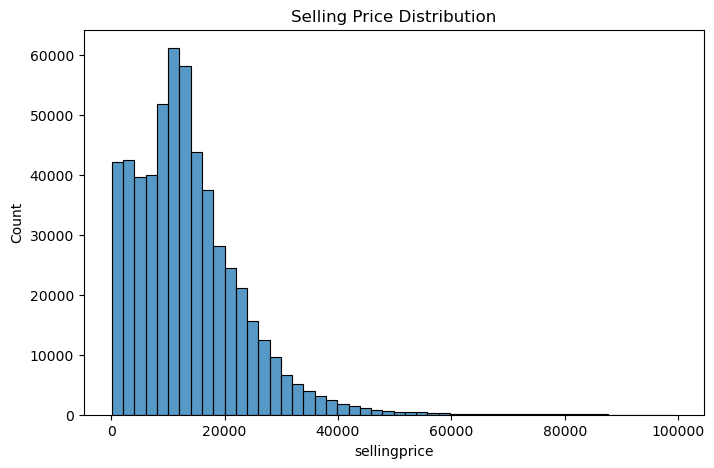

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['sellingprice'], bins=50)
plt.title("Selling Price Distribution")

Text(0.5, 1.0, 'Price vs Odometer')

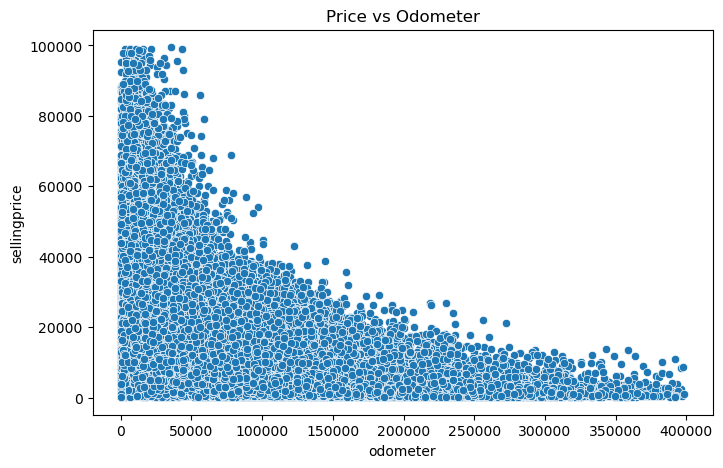

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['odometer'], y=df['sellingprice'])
plt.title("Price vs Odometer")

<Axes: xlabel='odometer', ylabel='sellingprice'>

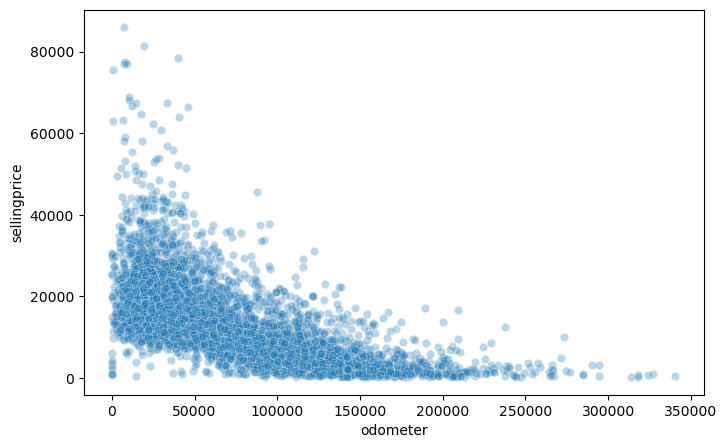

In [27]:
df_sample = df.sample(5000)

plt.figure(figsize=(8,5))
sns.scatterplot(x=df_sample['odometer'], y=df_sample['sellingprice'], alpha=0.3)

# Log

In [28]:
df['odometer_log'] = np.log1p(df['odometer'])
df['price_log'] = np.log1p(df['sellingprice'])

Text(0.5, 1.0, 'Price vs Odometer')

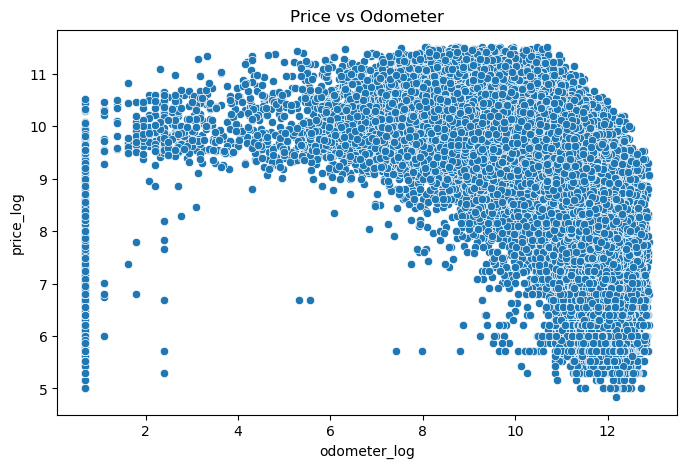

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['odometer_log'], y=df['price_log'])
plt.title("Price vs Odometer")

In [ ]:
df = df[df['odometer_log'] > 2]# Remove outliers

Text(0.5, 1.0, 'Price vs Odometer')

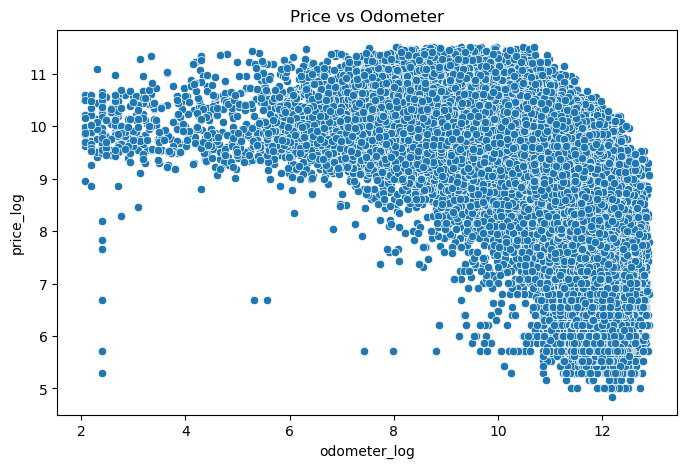

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['odometer_log'], y=df['price_log'])
plt.title("Price vs Odometer")

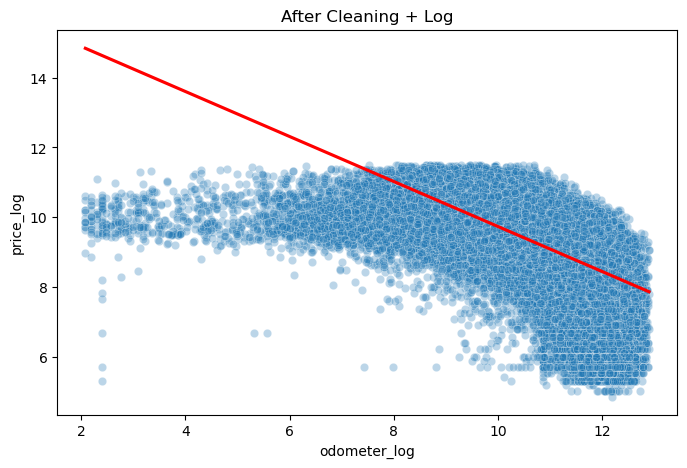

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['odometer_log'],
    y=df['price_log'],
    alpha=0.3
)

sns.regplot(
    x=df['odometer_log'],
    y=df['price_log'],
    scatter=False,
    color='red'
)

plt.title("After Cleaning + Log")
plt.show()

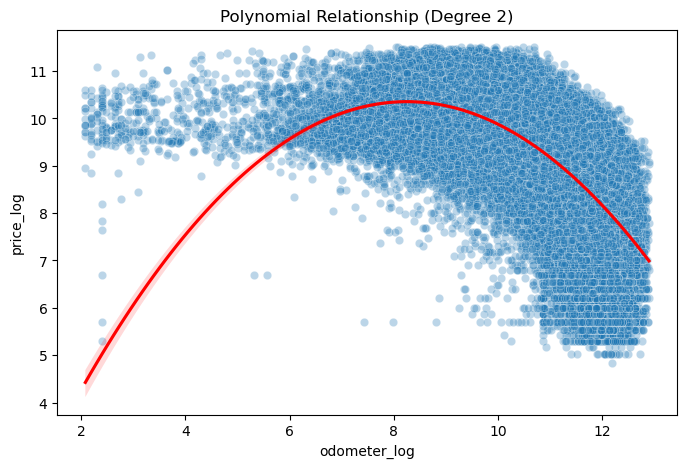

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['odometer_log'],
    y=df['price_log'],
    alpha=0.3
)

# Polynomial Curve
sns.regplot(
    x=df['odometer_log'],
    y=df['price_log'],
    order=2,  # منحنى
    scatter=False,
    color='red'
)

plt.title("Polynomial Relationship (Degree 2)")
plt.show()

In [34]:
df['car_age'] = df['sale_year'] - df['year']

In [35]:
df['odo_age_interaction'] = df['odometer'] * df['car_age']

# Top Car Brands

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Ford'),
  Text(1, 0, 'Chevrolet'),
  Text(2, 0, 'Nissan'),
  Text(3, 0, 'Toyota'),
  Text(4, 0, 'Dodge'),
  Text(5, 0, 'Honda'),
  Text(6, 0, 'Hyundai'),
  Text(7, 0, 'BMW'),
  Text(8, 0, 'Kia'),
  Text(9, 0, 'Chrysler')])

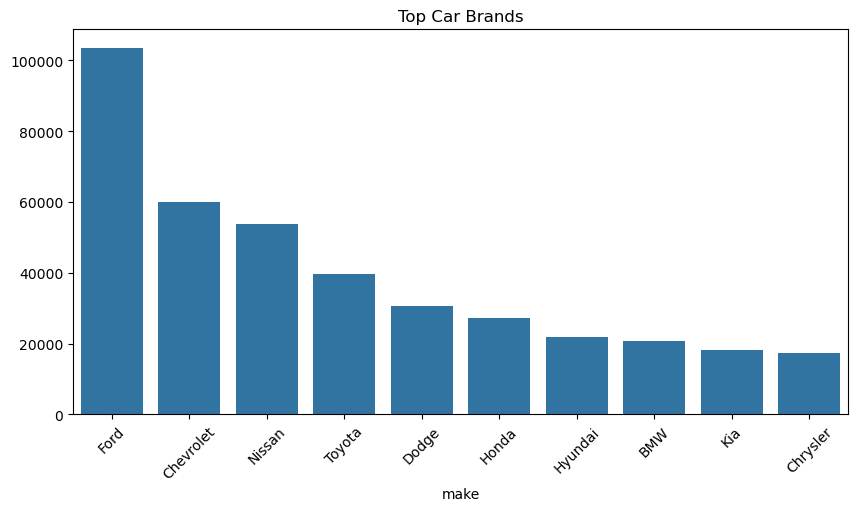

In [36]:
top_brands = df['make'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top Car Brands")
plt.xticks(rotation=45)

# The Effect of the Type of Fittes

In [37]:
df.groupby('transmission')['sellingprice'].mean()

transmission
Sedan        13585.714286
automatic    13531.769211
manual       11219.436656
sedan        13600.000000
unknown      14794.397450
Name: sellingprice, dtype: float64

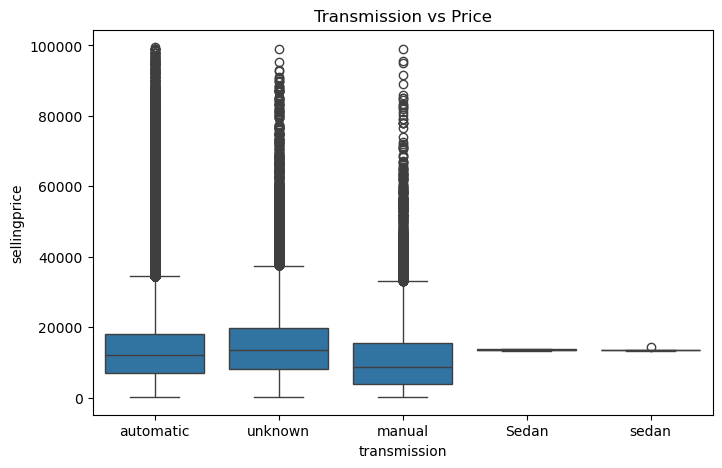

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['transmission'], y=df['sellingprice'])
plt.title("Transmission vs Price")
plt.show()

In [63]:
df['transmission'].unique()

array(['automatic', 'unknown', 'manual', 'Sedan', 'sedan'], dtype=object)

In [64]:
df = df[df['transmission'].isin(['automatic', 'manual', 'unknown'])]

Text(0.5, 1.0, 'Transmission vs Log Price')

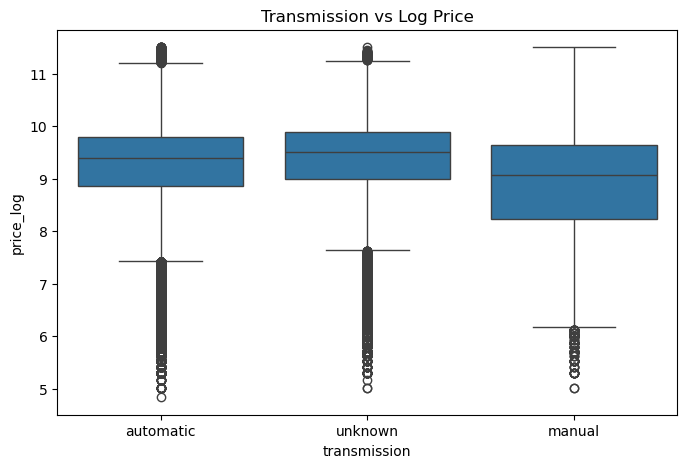

In [65]:
df['price_log'] = np.log1p(df['sellingprice'])

plt.figure(figsize=(8,5))
sns.boxplot(x=df['transmission'], y=df['price_log'])
plt.title("Transmission vs Log Price")

In [40]:
df['is_automatic'] = df['transmission'].apply(lambda x: 1 if x == 'automatic' else 0) #Encoding

In [ ]:
df['auto_age'] = df['is_automatic'] * df['car_age']
# العربية الأوتوماتيك: بتحتفظ بسعرها أكتر مع مرور الوقت
#                    العربية المانيوال: سعرها بيقل أسرع 

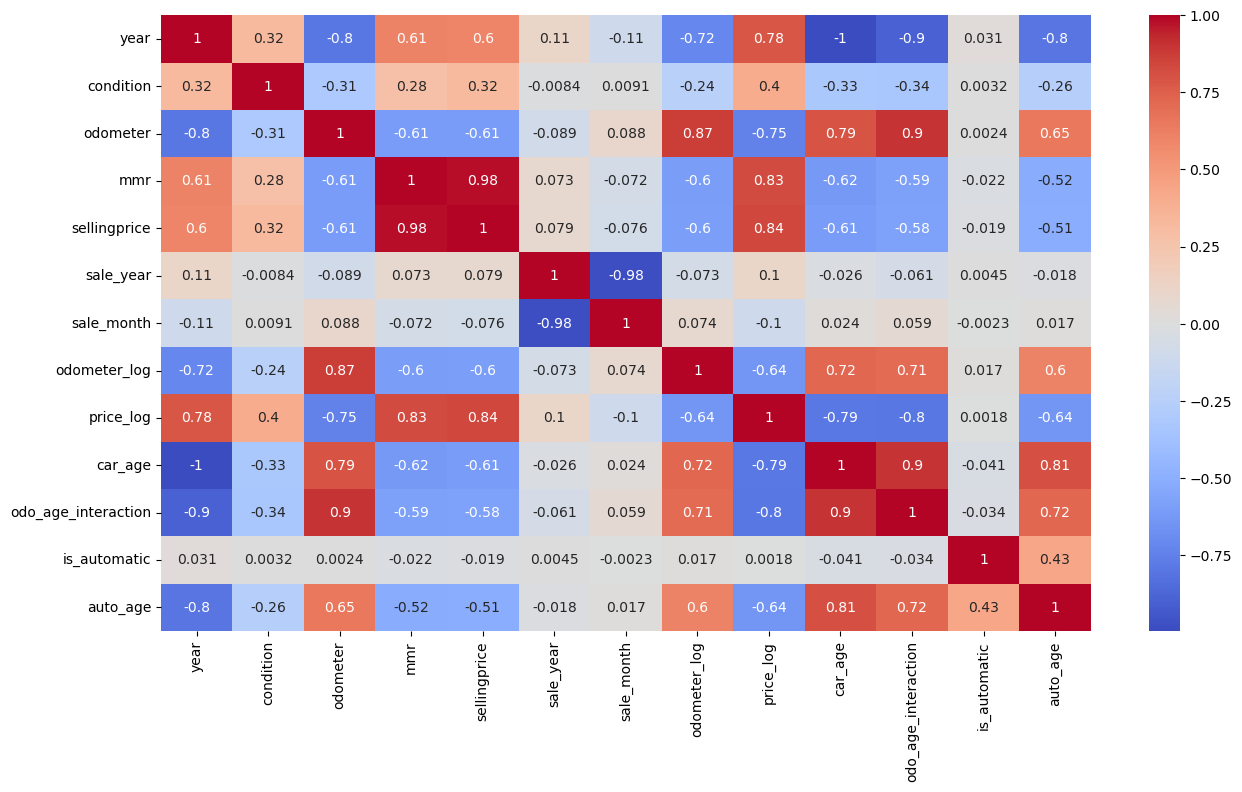

In [42]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [43]:
df.drop(['saledate','vin','state','price_log'], axis=1,inplace=True)


In [44]:
df['price_diff'] = df['sellingprice'] - df['mmr']

In [45]:
X = df.drop(columns=['sellingprice', 'price_diff'])
y = df['price_diff']

In [46]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

In [48]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [49]:
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=50,random_state=42 ,n_jobs=-1 ,max_depth=15))
])

In [50]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['year', 'condition', 'odometer', 'mmr', 'sale_year', 'sale_month',
       'odometer_log', 'car_age', 'odo_age_interaction', 'is_automatic',
       'auto_age'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior',
       'seller'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [ ]:
y_pred_diff = model_pipeline.predict(X_test)
# رجع السعر الحقيقي
y_pred_final = X_test['mmr'] + y_pred_diff

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(df.loc[X_test.index, 'sellingprice'], y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(df.loc[X_test.index, 'sellingprice'], y_pred_final)))
print("R2:", r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_final))

MAE: 928.4942362817891
RMSE: 1482.818424494437
R2: 0.9759697779427708


In [53]:
import joblib

joblib.dump(model_pipeline, "car_price_model.pkl")

['car_price_model.pkl']

In [54]:
model = model_pipeline.named_steps['model']

importances = model.feature_importances_

feature_names = model_pipeline.named_steps['preprocessing'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

feat_imp.head(20)

,feature,importance
1,num__condition,0.367728
3,num__mmr,0.173036
7327,cat__seller_enterprise vehicle exchange / tra ...,0.075269
8795,cat__seller_hertz/tra,0.045255
0,num__year,0.036357
2,num__odometer,0.026040
6,num__odometer_log,0.024613
8,num__odo_age_interaction,0.012283
3290,cat__seller_aaero sweet company,0.005275
1239,cat__trim_2500 170 WB Cargo,0.004940


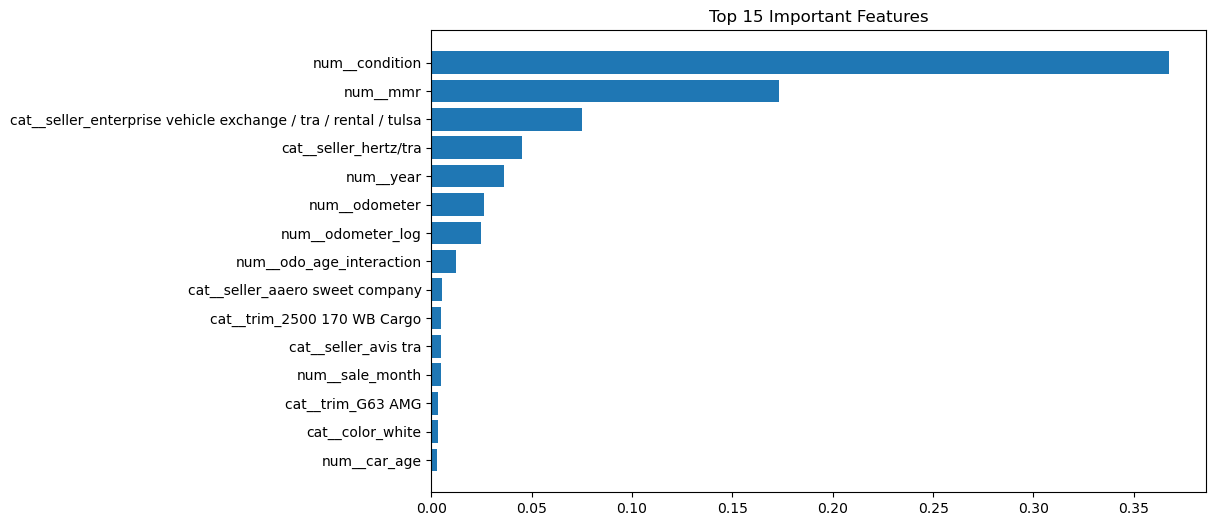

In [55]:
top_features = feat_imp.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

In [56]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

y_pred_lr_diff = lr_pipeline.predict(X_test)
y_pred_lr_final = X_test['mmr'] + y_pred_lr_diff

print("Linear Regression R2:", r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_lr_final))

Linear Regression R2: 0.9739456376262411


In [57]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])
dt_pipeline.fit(X_train, y_train)

y_pred_dt_diff = dt_pipeline.predict(X_test)
y_pred_dt_final = X_test['mmr'] + y_pred_dt_diff

print("Decision Tree R2:", r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_dt_final))

Decision Tree R2: 0.9588448179712731


In [58]:
print(f"Random Forest R2: {r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_final)}")
print(f"Linear Regression R2: {r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_lr_final)}")
print(f"Decision Tree R2: {r2_score(df.loc[X_test.index, 'sellingprice'], y_pred_dt_final)}")

Random Forest R2: 0.9759697779427708
Linear Regression R2: 0.9739456376262411
Decision Tree R2: 0.9588448179712731


In [59]:
new_car = pd.DataFrame([{
    'year': 2018,
    'make': 'Toyota',
    'model': 'Camry',
    'trim': 'SE',
    'body': 'Sedan',
    'transmission': 'automatic',
    'condition': 35,
    'odometer': 60000,
    'color': 'white',
    'interior': 'black',
    'seller': 'dealer',
    'state': 'ca',
    'mmr': 15000
}])

In [60]:
def add_features(df):
    import numpy as np
    
    df = df.copy()
    
    df['sale_year'] = 2015
    df['sale_month'] = 1
    
    df['car_age'] = df['sale_year'] - df['year']
    
    df['odometer_log'] = np.log1p(df['odometer'])
    
    df['odo_age_interaction'] = df['odometer'] * df['car_age']
    
    df['is_automatic'] = (df['transmission'] == 'automatic').astype(int)
    
    df['auto_age'] = df['is_automatic'] * df['car_age']
    
    return df

In [61]:
new_car = add_features(new_car)

pred_diff = model_pipeline.predict(new_car)[0]

In [62]:
final_price = new_car['mmr'].values[0] + pred_diff

print("Final predicted price:", final_price)

Final predicted price: 13091.752558473203
